## Marco Adicional - Regressão Linear Simples

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

In [ ]:
dados=pd.read_csv('//content/bquxjob_29845c05_19678929241.csv')

In [ ]:
print(dados.head())
print(dados.shape)

  track_id  in_apple_playlists  in_apple_charts  in_deezer_playlists  \
0  4061483                  16                0                   54   
1  4487193                  19                0                    7   
2  8033263                  31                0                   19   
3  3635714                   0                0                    3   
4  5939675                  21                0                  386   

   in_deezer_charts  in_shazam_charts track_id_1  \
0                 0               0.0    4061483   
1                 0               0.0    4487193   
2                 0               2.0    8033263   
3                 0               0.0    3635714   
4                 0               NaN    5939675   

                          track_name_limpo      artist_name_limpo  \
0        Love Grows Where My Rosemary Goes      Edison Lighthouse   
1  Paulo Londra Bzrp Music Sessions Vol 23  Bizarrap Paulo Londra   
2                                    SloMo     

In [ ]:
print(dados.dtypes)

track_id                 object
in_apple_playlists        int64
in_apple_charts           int64
in_deezer_playlists       int64
in_deezer_charts          int64
in_shazam_charts        float64
track_id_1               object
track_name_limpo         object
artist_name_limpo        object
artist_count              int64
released_year             int64
released_month            int64
released_day              int64
in_spotify_playlists      int64
in_spotify_charts         int64
streams_limpo           float64
track_id_2               object
bpm                       int64
danceability_%            int64
valence_%                 int64
energy_%                  int64
acousticness_%            int64
instrumentalness_%        int64
liveness_%                int64
speechiness_%             int64
dtype: object


In [ ]:
# Separar X e Y
X = dados['bpm'].astype(float).values
Y = dados['streams_limpo'].astype(float).values


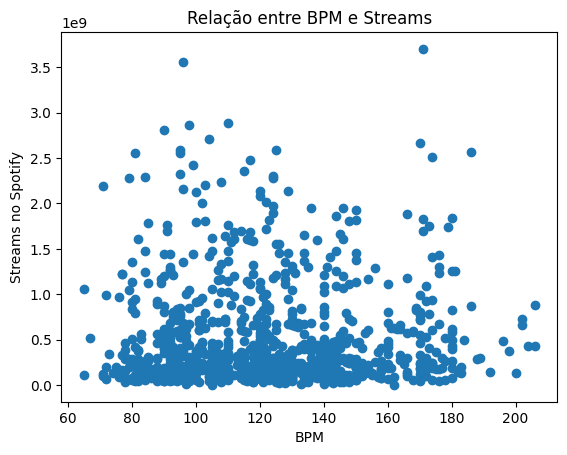

Coeficiente de correlação: nan


In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Gráfico de dispersão
plt.scatter(X, Y)
plt.xlabel('BPM')
plt.ylabel('Streams no Spotify')
plt.title('Relação entre BPM e Streams')
plt.show()

# Cálculo do coeficiente de correlação de Pearson
r, _ = pearsonr(X, Y)
print(f'Coeficiente de correlação: {r:.4f}')


In [ ]:
# Eliminar linhas com valores ausentes
dados_limpos = dados[['bpm', 'streams_limpo']].dropna()

# Separar X e Y
X = dados_limpos['bpm'].astype(float).values
Y = dados_limpos['streams_limpo'].astype(float).values


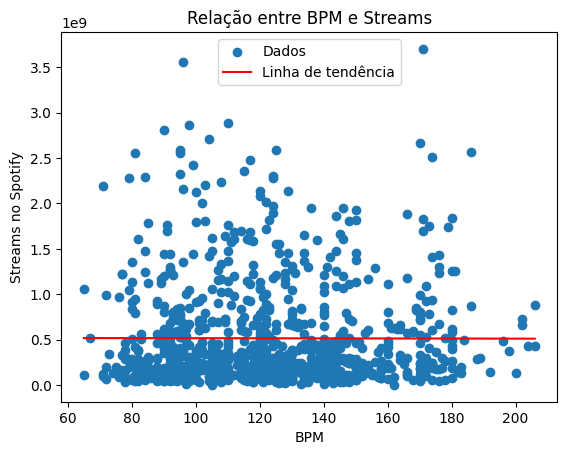

Coeficiente de correlação: -0.0024


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Scatter plot
plt.scatter(X, Y, label='Dados')

# Ajustar uma linha de regressão (reta y = a*x + b)
a, b = np.polyfit(X, Y, 1)  # 1 = grau 1 (reta)

# Gerar os valores da reta
x_reta = np.linspace(X.min(), X.max(), 100)
y_reta = a * x_reta + b

# Plotar a linha de tendência
plt.plot(x_reta, y_reta, color='red', label='Linha de tendência')

plt.xlabel('BPM')
plt.ylabel('Streams no Spotify')
plt.title('Relação entre BPM e Streams')
plt.legend()
plt.show()

# Correlação de Pearson
r, _ = pearsonr(X, Y)
print(f'Coeficiente de correlação: {r:.4f}')


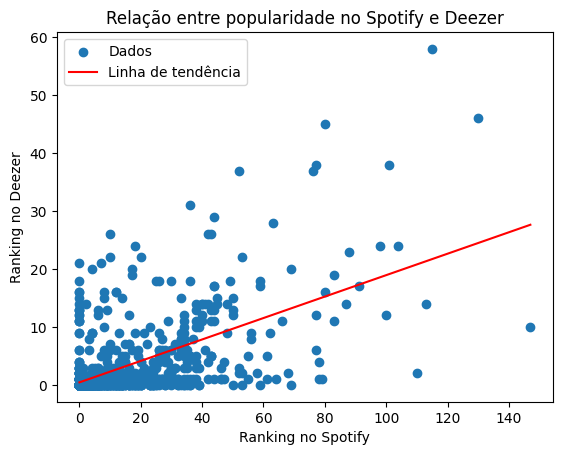

Coeficiente de correlação: 0.6002


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Separando as variáveis
X = dados['in_spotify_charts'].astype(float).values
Y = dados['in_deezer_charts'].astype(float).values

# Scatter plot
plt.scatter(X, Y, label='Dados')

# Ajuste da linha de regressão (reta y = a*x + b)
a, b = np.polyfit(X, Y, 1)  # 1 = grau 1 (reta)

# Gerando os valores da linha de tendência
x_reta = np.linspace(X.min(), X.max(), 100)
y_reta = a * x_reta + b

# Plotando a linha de tendência (vermelha)
plt.plot(x_reta, y_reta, color='red', label='Linha de tendência')

plt.xlabel('Ranking no Spotify')
plt.ylabel('Ranking no Deezer')
plt.title('Relação entre popularidade no Spotify e Deezer')
plt.legend()
plt.show()

# Correlação de Pearson
r, _ = pearsonr(X, Y)
print(f'Coeficiente de correlação: {r:.4f}')


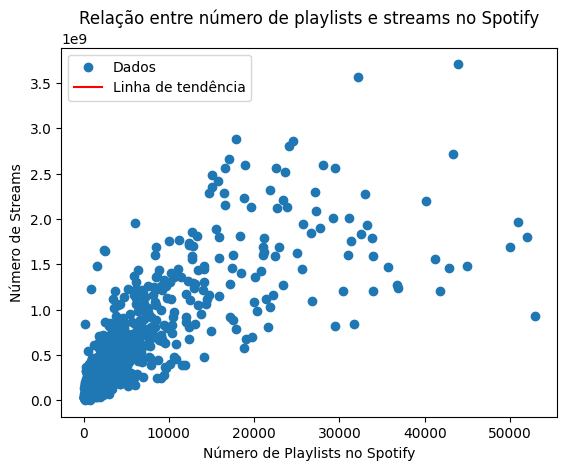

Coeficiente de correlação: nan


In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Separando as variáveis de interesse
X = dados['in_spotify_playlists'].astype(float).values
Y = dados['streams_limpo'].astype(float).values

# Scatter plot
plt.scatter(X, Y, label='Dados')

# Ajuste da linha de regressão (reta y = a*x + b)
a, b = np.polyfit(X, Y, 1)  # 1 = grau 1 (reta)

# Gerando os valores da linha de tendência
x_reta = np.linspace(X.min(), X.max(), 100)
y_reta = a * x_reta + b

# Plotando a linha de tendência (vermelha)
plt.plot(x_reta, y_reta, color='red', label='Linha de tendência')

plt.xlabel('Número de Playlists no Spotify')
plt.ylabel('Número de Streams')
plt.title('Relação entre número de playlists e streams no Spotify')
plt.legend()
plt.show()

# Correlação de Pearson
r, _ = pearsonr(X, Y)
print(f'Coeficiente de correlação: {r:.4f}')


In [ ]:
# Verificando se há valores ausentes
print(dados[['in_spotify_playlists', 'streams_limpo']].isnull().sum())

# Verificando a variação das variáveis
print(dados[['in_spotify_playlists', 'streams_limpo']].nunique())


in_spotify_playlists    0
streams_limpo           1
dtype: int64
in_spotify_playlists    879
streams_limpo           948
dtype: int64


In [ ]:
# Remover linhas com valores NaN
dados_clean = dados.dropna(subset=['in_spotify_playlists', 'streams_limpo'])

# Recalcular as variáveis de interesse
X = dados_clean['in_spotify_playlists'].astype(float).values
Y = dados_clean['streams_limpo'].astype(float).values

# Recalcular a correlação de Pearson
r, _ = pearsonr(X, Y)
print(f'Coeficiente de correlação: {r:.4f}')


Coeficiente de correlação: 0.7898


In [ ]:
# Verificando se há valores ausentes (NaN)
print(dados[['in_spotify_playlists', 'streams_limpo']].isnull().sum())

# Verificando a quantidade de valores únicos
print(dados[['in_spotify_playlists', 'streams_limpo']].nunique())

# Remover linhas com valores NaN
dados_clean = dados.dropna(subset=['in_spotify_playlists', 'streams_limpo'])

# Recalcular as variáveis de interesse
X = dados_clean['in_spotify_playlists'].astype(float).values
Y = dados_clean['streams_limpo'].astype(float).values


in_spotify_playlists    0
streams_limpo           1
dtype: int64
in_spotify_playlists    879
streams_limpo           948
dtype: int64


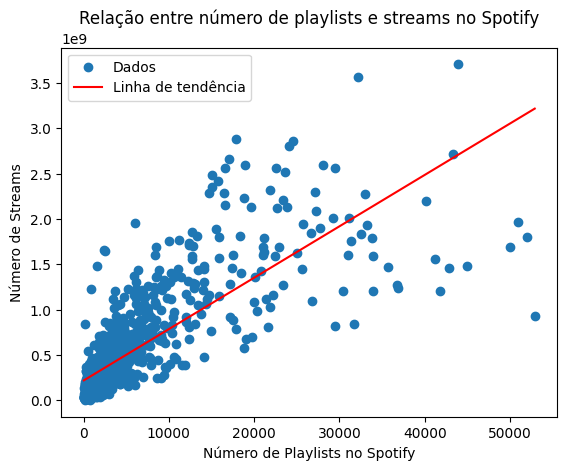

Coeficiente de correlação: 0.7898


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Scatter plot
plt.scatter(X, Y, label='Dados')

# Ajuste da linha de regressão (reta y = a*x + b)
a, b = np.polyfit(X, Y, 1)  # 1 = grau 1 (reta)

# Gerando os valores da linha de tendência
x_reta = np.linspace(X.min(), X.max(), 100)
y_reta = a * x_reta + b

# Plotando a linha de tendência (vermelha)
plt.plot(x_reta, y_reta, color='red', label='Linha de tendência')

plt.xlabel('Número de Playlists no Spotify')
plt.ylabel('Número de Streams')
plt.title('Relação entre número de playlists e streams no Spotify')
plt.legend()
plt.show()

# Correlação de Pearson
r, _ = pearsonr(X, Y)
print(f'Coeficiente de correlação: {r:.4f}')


In [ ]:
# Agrupar por artista e calcular o número total de músicas e o total de streams
dados_agrupados = dados.groupby('artist_name_limpo').agg(
    qtd_musicas=('track_id', 'count'),  # Contando o número de músicas por artista
    total_streams=('streams_limpo', 'sum')  # Somando os streams por artista
).reset_index()

# Visualizar os primeiros resultados
print(dados_agrupados.head())


               artist_name_limpo  qtd_musicas  total_streams
0                21 Savage Gunna            1   6.068094e+07
1             24kgoldn Iann Dior            1   1.699402e+09
2                        50 Cent            1   1.202723e+09
3  AAP Rocky Metro Boomin Roisee            1   9.418647e+07
4       Abhijay Sharma Riar Saab            1   7.100714e+07


In [ ]:
from scipy.stats import pearsonr

# Extrair as variáveis
X = dados_agrupados['qtd_musicas'].values
Y = dados_agrupados['total_streams'].values

# Calcular o coeficiente de correlação de Pearson
r, _ = pearsonr(X, Y)
print(f'Coeficiente de correlação: {r:.4f}')


Coeficiente de correlação: 0.7809


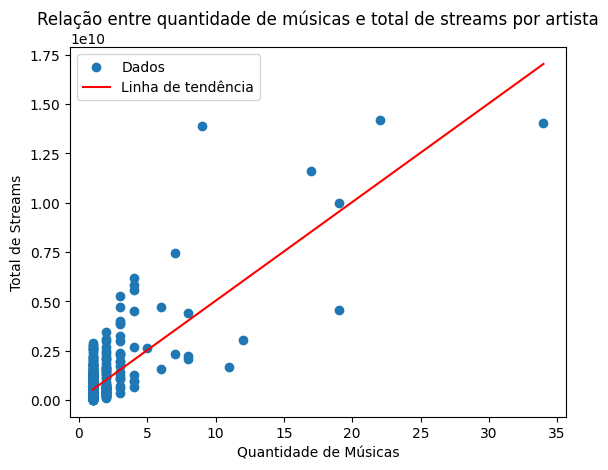

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Scatter plot
plt.scatter(X, Y, label='Dados')

# Ajuste da linha de regressão (reta y = a*x + b)
a, b = np.polyfit(X, Y, 1)  # 1 = grau 1 (reta)

# Gerando os valores da linha de tendência
x_reta = np.linspace(X.min(), X.max(), 100)
y_reta = a * x_reta + b

# Plotando a linha de tendência (vermelha)
plt.plot(x_reta, y_reta, color='red', label='Linha de tendência')

plt.xlabel('Quantidade de Músicas')
plt.ylabel('Total de Streams')
plt.title('Relação entre quantidade de músicas e total de streams por artista')
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import statsmodels.api as sm

# Selecionar as variáveis independentes (X) e a variável dependente (Y)
X = dados[['bpm', 'danceability_%', 'valence_%', 'energy_%',
           'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']]
Y = dados['streams_limpo']

# Remover possíveis linhas com valores ausentes
X = X.dropna()
Y = Y[X.index]

# Adicionar constante (intercepto) para o modelo
X = sm.add_constant(X)

# Ajustar modelo de regressão linear
modelo = sm.OLS(Y, X).fit()

# Exibir o resumo da regressão
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:          streams_limpo   R-squared:                         nan
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Wed, 30 Apr 2025   Prob (F-statistic):                nan
Time:                        17:53:33   Log-Likelihood:                    nan
No. Observations:                 953   AIC:                               nan
Df Residuals:                     944   BIC:                               nan
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                     nan       

In [ ]:
features = ['bpm', 'danceability_%', 'valence_%', 'energy_%',
            'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']

# Remover linhas com valores ausentes
dados_limpos = dados.dropna(subset=['streams_limpo'] + features)

# Conferir se tem colunas com valores iguais
print(dados_limpos[features].nunique())

# Preparar X e Y
X = dados_limpos[features]
Y = dados_limpos['streams_limpo']

# Rodar regressão
import statsmodels.api as sm
X = sm.add_constant(X)
modelo = sm.OLS(Y, X).fit()
print(modelo.summary())


bpm                   124
danceability_%         72
valence_%              94
energy_%               80
acousticness_%         98
instrumentalness_%     39
liveness_%             68
speechiness_%          48
dtype: int64
                            OLS Regression Results                            
Dep. Variable:          streams_limpo   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     3.558
Date:                Wed, 30 Apr 2025   Prob (F-statistic):           0.000450
Time:                        17:53:33   Log-Likelihood:                -20524.
No. Observations:                 952   AIC:                         4.107e+04
Df Residuals:                     943   BIC:                         4.111e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                               

## Regressão Linear (Parte 2) - Gráficos com PACOTE MATPLOTLIB










In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

def plot_regressao_linear(x, y, titulo='', xlabel='', ylabel='', cor_pontos='blue', cor_linha='red'):
    # Remove valores nulos
    x = np.array(x)
    y = np.array(y)
    mask = ~np.isnan(x) & ~np.isnan(y)
    x = x[mask]
    y = y[mask]

    # Ajusta a regressão
    x_reshape = x.reshape(-1, 1)
    modelo = LinearRegression()
    modelo.fit(x_reshape, y)
    y_pred = modelo.predict(x_reshape)

    # Plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=x, y=y, color=cor_pontos, alpha=0.6, edgecolor='k', s=70, label='Observações')
    plt.plot(x, y_pred, color=cor_linha, linewidth=2.5, label='Regressão linear')

    # Personalização
    plt.title(titulo, fontsize=16, fontweight='bold')
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


HIPÓTESE 1

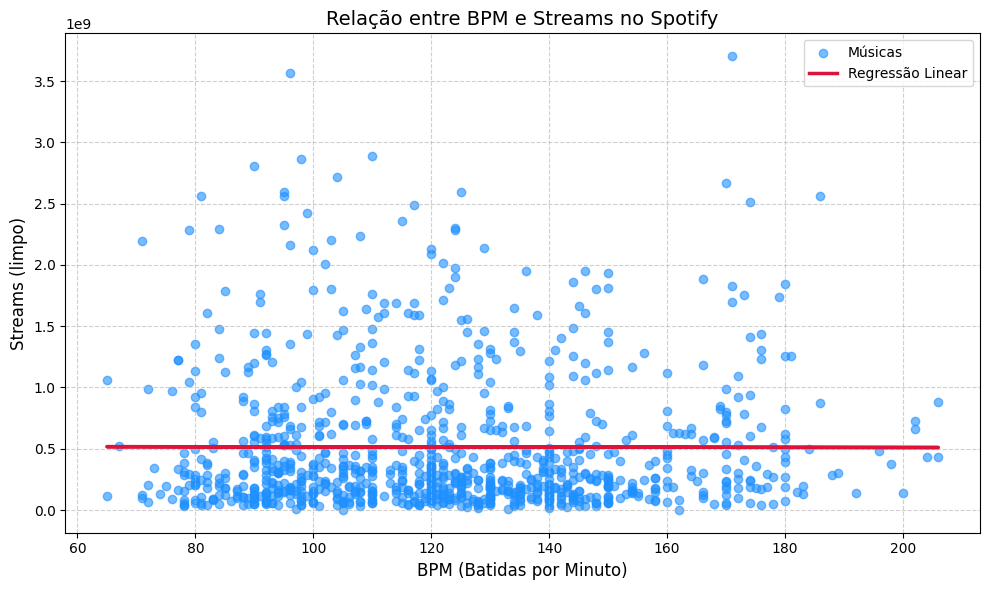

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Remove valores ausentes
dados_filtrados = dados[['bpm', 'streams_limpo']].dropna()

# Separando variáveis X e Y
X = dados_filtrados['bpm'].values.reshape(-1, 1)
Y = dados_filtrados['streams_limpo'].values.reshape(-1, 1)

# Criando o modelo de regressão linear
modelo = LinearRegression()
modelo.fit(X, Y)

# Fazendo previsões para a linha de regressão
Y_pred = modelo.predict(X)

# Criando o gráfico
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.6, color='dodgerblue', label='Músicas')
plt.plot(X, Y_pred, color='crimson', linewidth=2.5, label='Regressão Linear')
plt.title('Relação entre BPM e Streams no Spotify', fontsize=14)
plt.xlabel('BPM (Batidas por Minuto)', fontsize=12)
plt.ylabel('Streams (limpo)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


HIPÓTESE 2

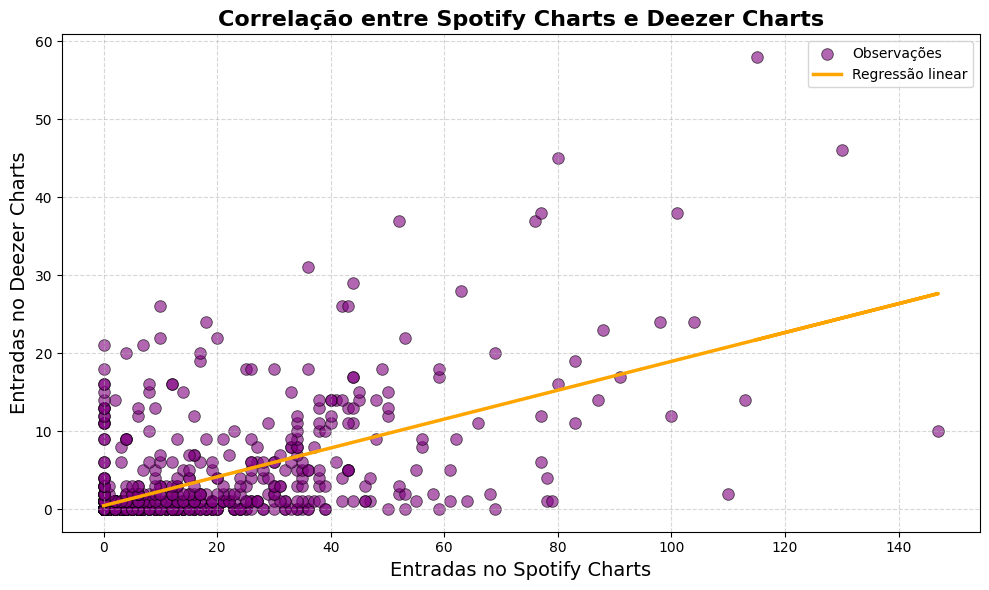

In [ ]:
plot_regressao_linear(
    x=dados['in_spotify_charts'],
    y=dados['in_deezer_charts'],
    titulo='Correlação entre Spotify Charts e Deezer Charts',
    xlabel='Entradas no Spotify Charts',
    ylabel='Entradas no Deezer Charts',
    cor_pontos='purple',
    cor_linha='orange'
)


HIPÓTESE 3

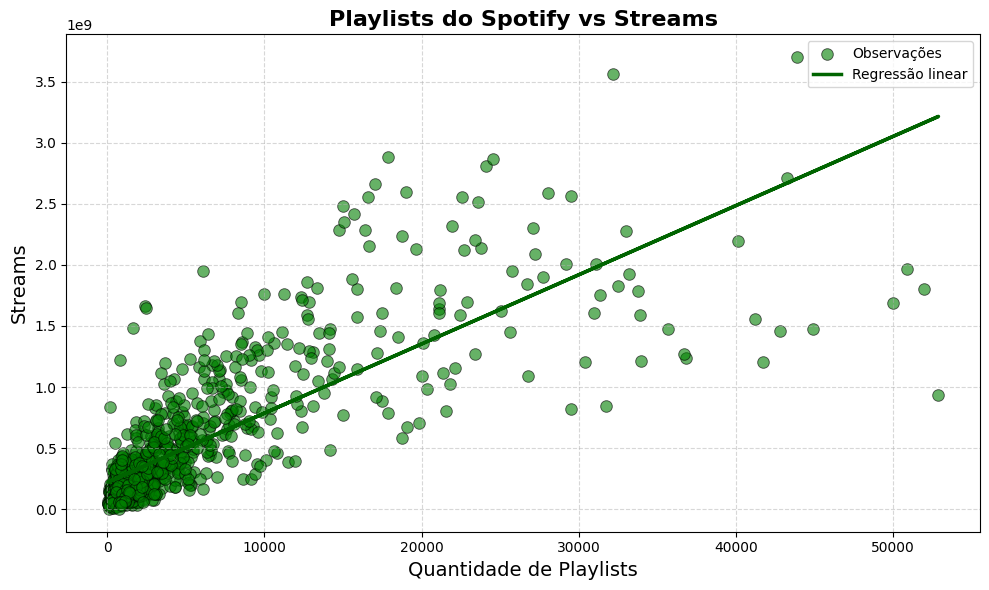

In [ ]:
plot_regressao_linear(
    x=dados['in_spotify_playlists'],
    y=dados['streams_limpo'],
    titulo='Playlists do Spotify vs Streams',
    xlabel='Quantidade de Playlists',
    ylabel='Streams',
    cor_pontos='green',
    cor_linha='darkgreen'
)


HIPÓTESE 4

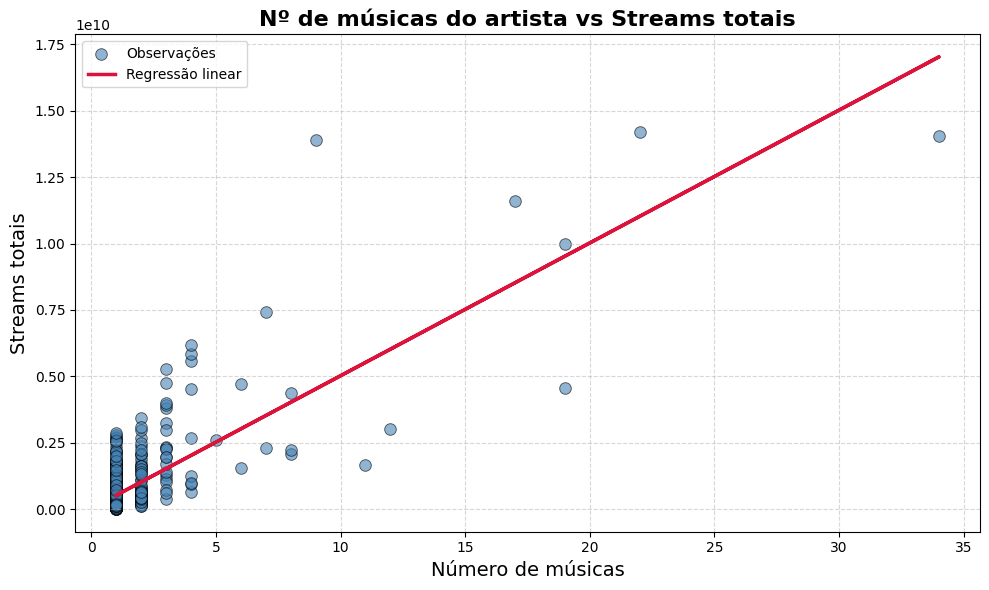

In [ ]:
# Você precisa ter um DataFrame agrupado por artista, exemplo:
agrupado = dados.groupby('artist_name_limpo').agg({
    'track_id': 'count',
    'streams_limpo': 'sum'
}).rename(columns={'track_id': 'qtd_musicas'})

plot_regressao_linear(
    x=agrupado['qtd_musicas'],
    y=agrupado['streams_limpo'],
    titulo='Nº de músicas do artista vs Streams totais',
    xlabel='Número de músicas',
    ylabel='Streams totais',
    cor_pontos='steelblue',
    cor_linha='crimson'
)


HIPÓTESE 5

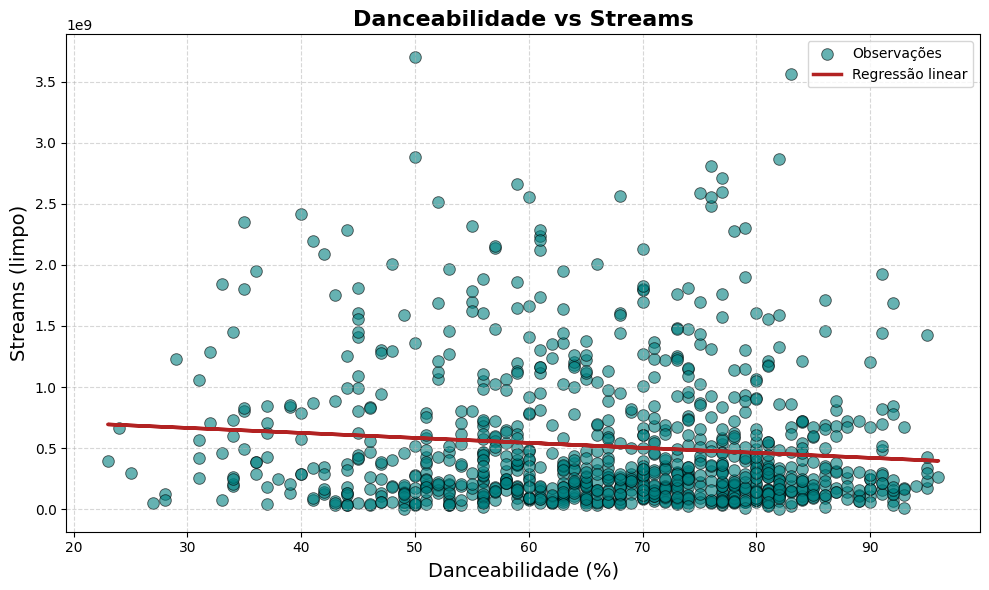

In [ ]:
plot_regressao_linear(
    x=dados['danceability_%'],
    y=dados['streams_limpo'],
    titulo='Danceabilidade vs Streams',
    xlabel='Danceabilidade (%)',
    ylabel='Streams (limpo)',
    cor_pontos='teal',
    cor_linha='firebrick'
)


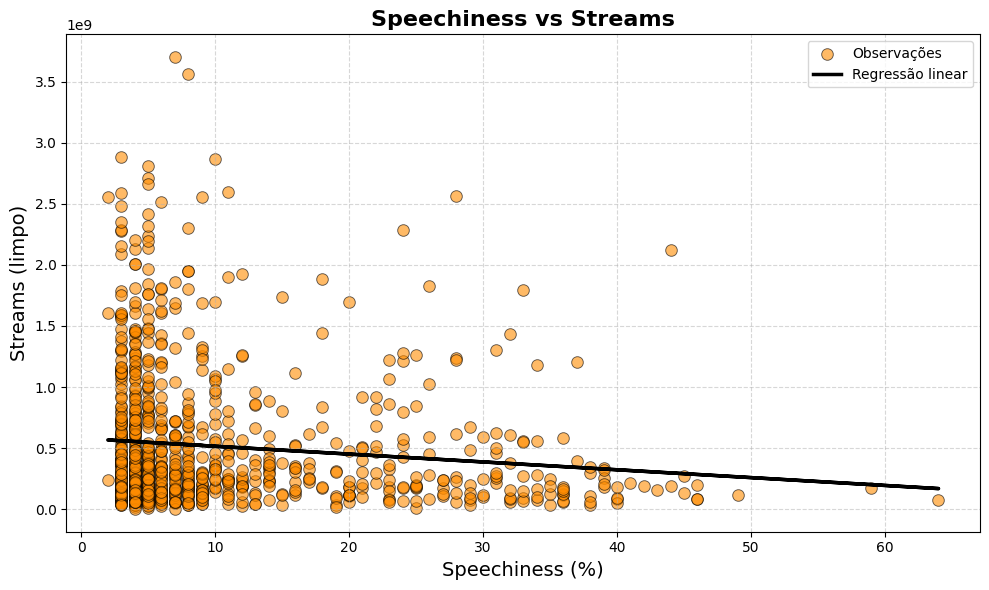

In [ ]:
plot_regressao_linear(
    x=dados['speechiness_%'],
    y=dados['streams_limpo'],
    titulo='Speechiness vs Streams',
    xlabel='Speechiness (%)',
    ylabel='Streams (limpo)',
    cor_pontos='darkorange',
    cor_linha='black'
)


HIPÓTESE 5 - GRÁFICOS EM LOOP

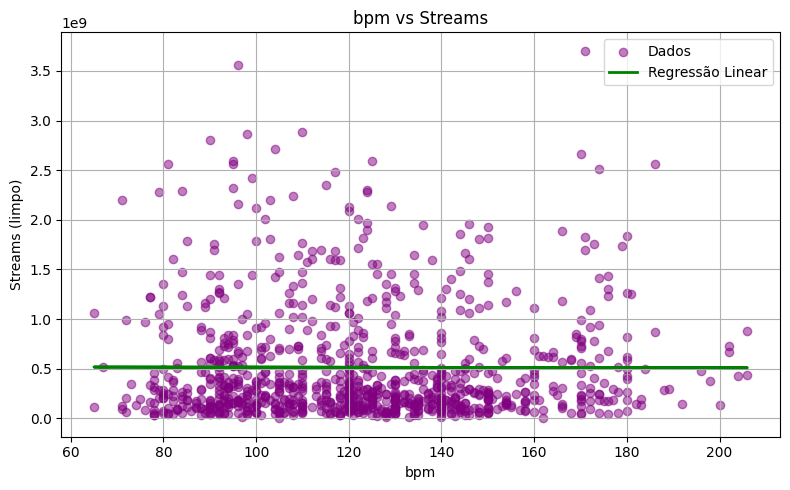

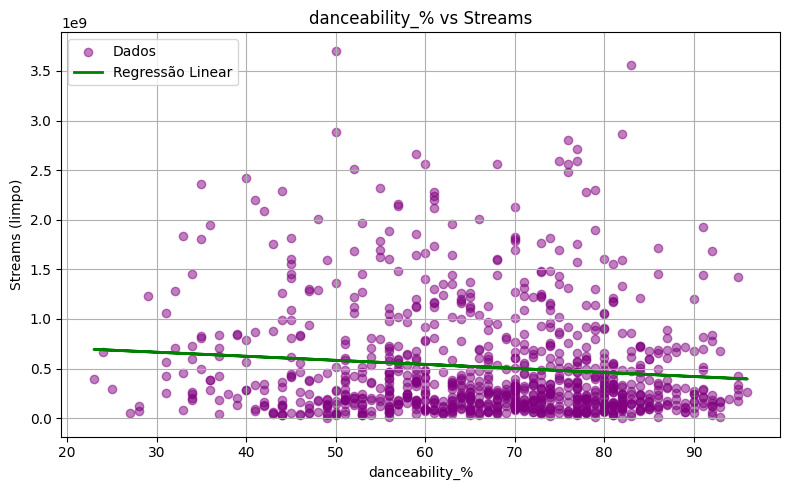

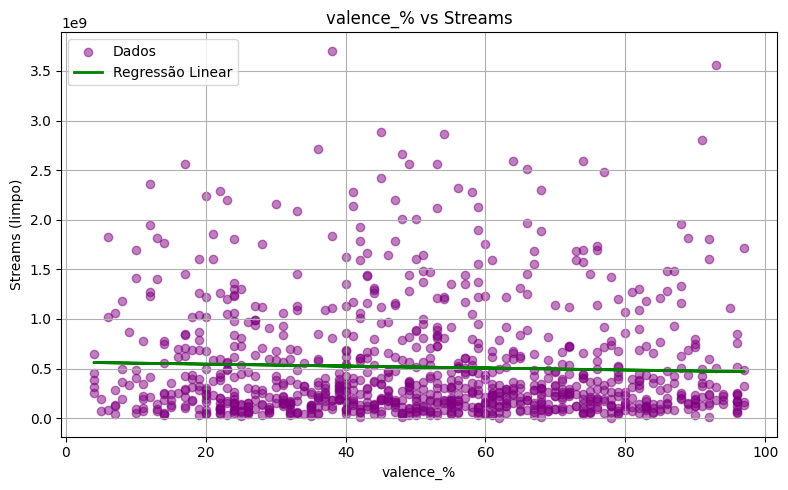

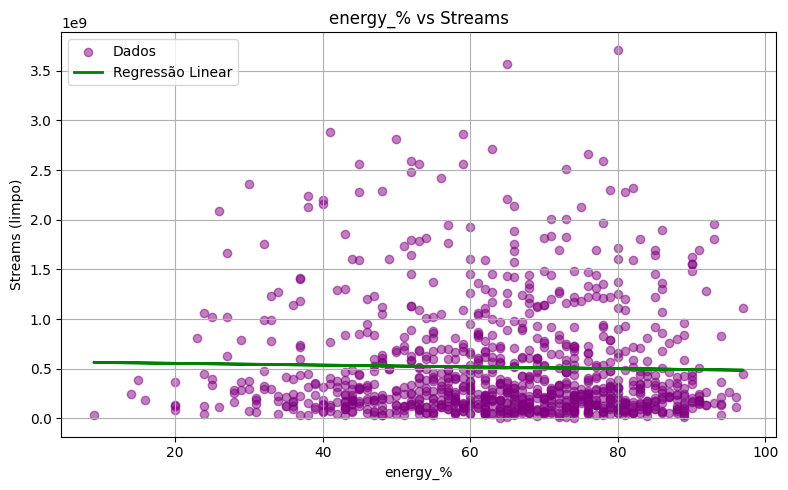

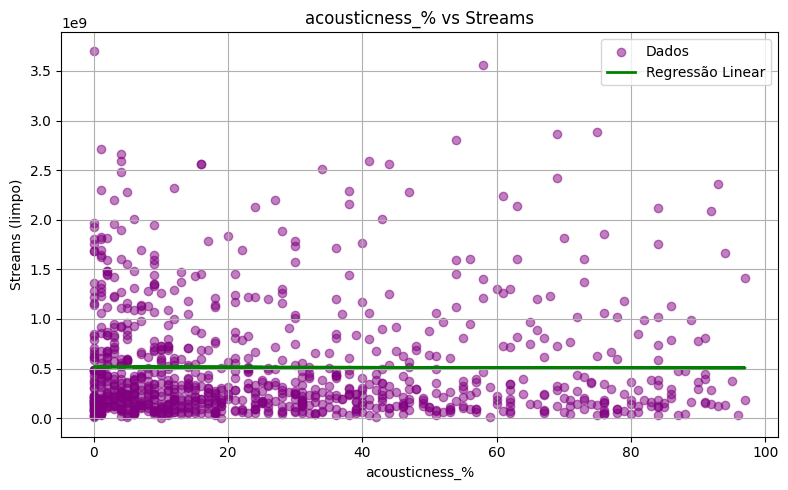

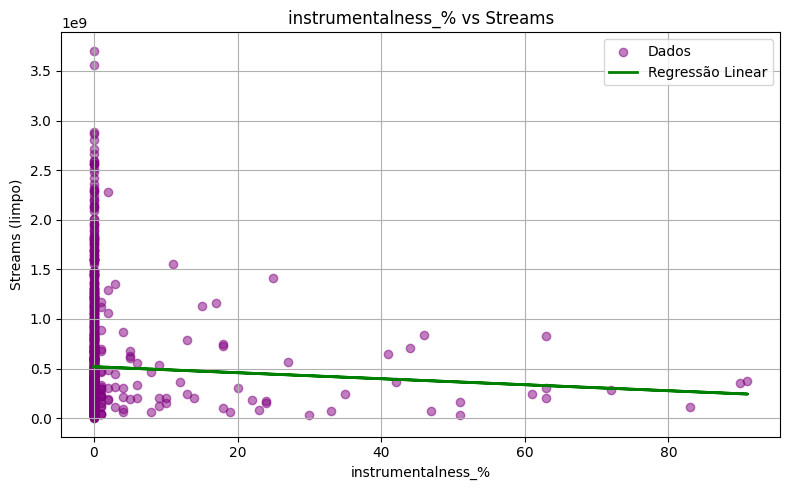

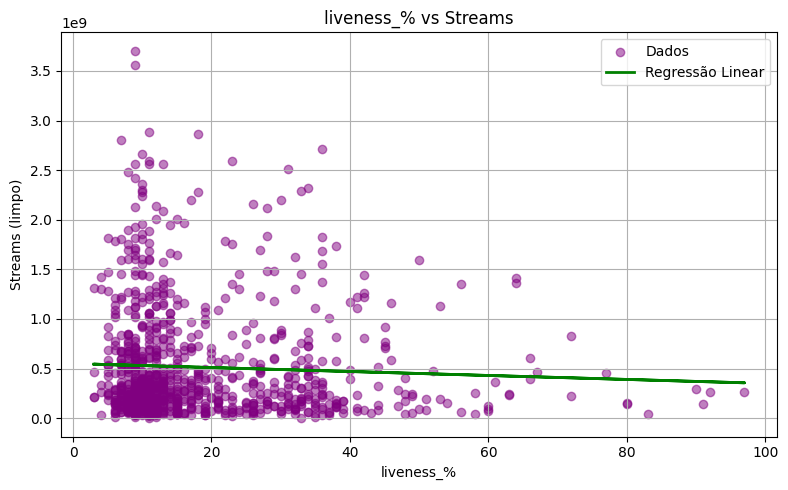

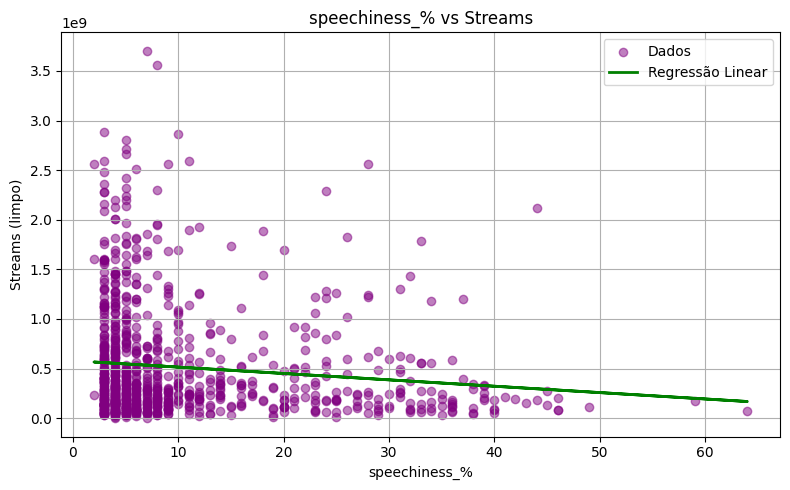

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Função para criar gráfico com regressão linear
def plot_regressao_linear(x, y, titulo, xlabel, ylabel, cor_pontos='blue', cor_linha='red'):
    # Remove pares onde x ou y têm NaN
    mascara = ~(x.isna() | y.isna())
    x = x[mascara]
    y = y[mascara]

    x_reshape = x.values.reshape(-1, 1)
    y_reshape = y.values.reshape(-1, 1)

    modelo = LinearRegression()
    modelo.fit(x_reshape, y_reshape)
    y_pred = modelo.predict(x_reshape)

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, alpha=0.5, color=cor_pontos, label='Dados')
    plt.plot(x, y_pred, color=cor_linha, linewidth=2, label='Regressão Linear')
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Lista das variáveis técnicas
variaveis = ['bpm', 'danceability_%', 'valence_%', 'energy_%',
             'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']

# Gerar gráficos automaticamente
for var in variaveis:
    plot_regressao_linear(
        x=dados[var],
        y=dados['streams_limpo'],
        titulo=f'{var} vs Streams',
        xlabel=var,
        ylabel='Streams (limpo)',
        cor_pontos='purple',
        cor_linha='green'
    )
